<a href="https://colab.research.google.com/github/kiran-web-development/FML-LAB-EXPERIMENT--20CS1105/blob/master/CNNMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN for the MNIST Dataset**

**Import libraries**

In [18]:
import numpy
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
#from keras.layers.convolutional import Convolution2D
#from keras.layers.convolutional import MaxPooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D
#from keras.utils import np_utils
from tensorflow.keras.utils import to_categorical
from keras import backend as K
#K.tensorflow_backend.set_image_dim_ordering('th')
#from keras as backend as K
#K.set_image_dim_ordering('th')
K.set_image_data_format('channels_last')
#print(keras.__version__)
from keras import __version__
print('Using Keras version:', __version__, 'backend:', K.backend())

Using Keras version: 3.10.0 backend: tensorflow


In [19]:
%pip install tensorflow

In [20]:
seed = 7
numpy.random.seed(seed)

**Load the Dataset**

In [21]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [22]:
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(y_test.shape))

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


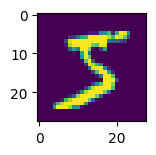

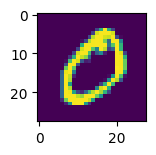

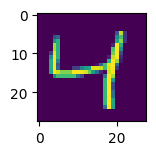

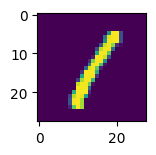

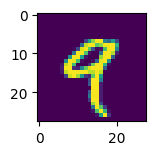

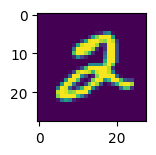

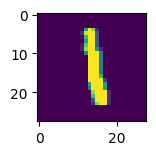

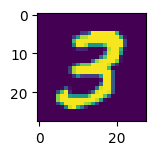

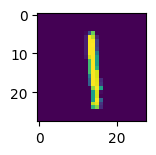

In [23]:
from matplotlib import pyplot
for i in range(9):
  img = X_train[i].reshape((28,28))
  pyplot.subplot(330 + 1 + i)
  pyplot.imshow(img)
  pyplot.show()

**reshape to be [samples][channels][width][height]**

In [24]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

**normalize inputs from 0-255 to 0-1**

In [25]:
X_train = X_train / 255
X_test = X_test / 255

**one hot encode outputs**

In [26]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
#y_train = np_utils.to_categorical(y_train)
#y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

**define a simple CNN model**

In [27]:
def baseline_model():
        # create model
        model = Sequential()
        #model.add(Convolution2D(32, 5, 5, input_shape=(1, 28, 28), activation='relu'))
        model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu'))
        model.add(Dense(num_classes, activation='softmax'))
        # Compile model
        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
        return model

**Build and Fit the model**

In [28]:
model = baseline_model()
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1, batch_size=200, verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.8559 - loss: 0.5087 - val_accuracy: 0.9739 - val_loss: 0.0877


**Final evaluation of the model**

In [29]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 2.61%
